In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner, learner_to_graph
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# Experiment Code

In [4]:
def stability_experiment(n_variables, n_factors, n_graphs, n_trials_per_graph, seed=1,
                         samp_size=500, epochs=100, lr=0.01, lambda_bp=1e-3, schedule=True):
    rng = np.random.default_rng(seed)
    results = []
    with tqdm(total=n_graphs*n_trials_per_graph) as pbar:
        for i in range(n_graphs):
            graph = generate_random_graph(n=n_variables, alphabet_size=2, n_factors=n_factors, rng=rng)
            samples = graph.sample(samp_size, seed=rng.integers(0,10000), progress=False)
            learner_res = {x : np.zeros(n_trials_per_graph) for x in ["KL", "SHD", "density", "avg_factor_size", "n_active_factors", "nce_loss"]}
            all_learners = []
            for j in range(n_trials_per_graph):
                ng = IndependentMarginals(samples, alphabet_size=2, alpha=1, seed=rng.integers(0,10000))
                lrn = FactorGraphLearner(
                    n_vars=n_variables,
                    alphabet_size=2,
                    K=n_variables,
                    noise_generator=ng,
                    hidden_dims=(16,16),
                    max_factor_size=5,
                    shared_mlp=False,
                    seed=rng.integers(0,10000)
                )
                ls, dg = lrn.train(
                    samples,
                    n_epochs=epochs,
                    lr=lr,
                    lambda_mask=0,
                    lambda_weight=0,
                    lambda_mlp_l2=1e-2,
                    lambda_bp=lambda_bp,
                    penalty_schedule=schedule,
                    verbose=False
                )
                learner_res["KL"][j] = kl_divergence(graph, lrn)
                learner_res["SHD"][j] = structural_hamming_distance(graph, lrn)
                learner_res["density"][j] = graph_density(lrn)
                learner_res["avg_factor_size"][j] = lrn.network.avg_factor_size().item()
                learner_res["n_active_factors"][j] = lrn.network.n_active_factors().item()
                learner_res["nce_loss"][j] = ls['Main'][-1]
                all_learners.append(lrn)
                pbar.update(1)
            cl_res = chow_liu(samples, 2)
            pairwise_shd = []
            for i in range(len(all_learners)):
                for j in range(i+1,len(all_learners)):
                    lrn_i, lrn_j = all_learners[i], all_learners[j]
                    pairwise_shd.append(structural_hamming_distance(lrn_i, lrn_j))
            data = {
                'graph' : graph,
                'samples' : samples,
                'chow_liu' : {
                    'graph' : cl_res,
                    'KL' : kl_divergence(graph, cl_res),
                    'SHD' : structural_hamming_distance(graph, cl_res),
                    'density' : 1,
                    'avg_factor_size' : (2 * n_variables - 1)/ n_variables,
                    'n_active_factors' : n_variables
                },
                'graph_metrics' : {
                    'KL' : kl_mle_optimal(graph, samples),
                    'density' : graph_density(graph),
                    'avg_factor_size' : np.mean([len(sc) for sc, f in graph.factors]),
                    'n_active_factors' : n_factors
                },
                'network_results' : learner_res,
                'pairwise_shd' : pairwise_shd
            }
            results.append(data)
    return results

In [5]:
results = stability_experiment(
    n_variables=12,
    n_factors=8,
    n_graphs=10,
    n_trials_per_graph=30,
    seed=549
)

100%|█████████████████████████████████████████| 300/300 [17:47<00:00,  3.56s/it]


# Exploration

In [25]:
def plot_stability_box(results, metric="KL", ylabel="", ax=None):
    n_graphs = len(results)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    data = [res['network_results'][metric] for res in results]
    bp = ax.boxplot(data, positions=np.arange(1, n_graphs+1), widths=0.6, patch_artist=True)
    for box in bp['boxes']:
        box.set(facecolor='lightblue', alpha=0.6)

    if metric in results[0]['chow_liu']:
        cl_vals = [res['chow_liu'][metric] for res in results]
        ax.scatter(np.arange(1, n_graphs+1), cl_vals, 
                   color='C1', label='Chow-Liu', zorder=3, s=60)

    if metric in results[0]['graph_metrics']:
        graph_vals = [res['graph_metrics'][metric] for res in results]
        lab = 'MLE' if metric == 'KL' else 'Ground Truth'
        ax.scatter(np.arange(1, n_graphs+1), graph_vals, 
                   color='C2', label=lab, zorder=3, s=60)
        
    ax.set_xlabel("Graph Index")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Stability Across Random Initializations ({metric})")
    ax.legend()
    # plt.tight_layout()
    # plt.show()

In [42]:
def plot_pairwise_shd(results, ax=None):
    data = [res['pairwise_shd'] for res in results]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data, positions=np.arange(1, len(data)+1), widths=0.6, patch_artist=True)
    for box in bp['boxes']:
        box.set(facecolor='lightblue', alpha=0.6)

    ax.set_xlabel("Graph Index")
    ax.set_ylabel("Pairwise SHD between runs")
    ax.set_title("Stability of Learned Structures")
    # plt.tight_layout()
    # plt.show()

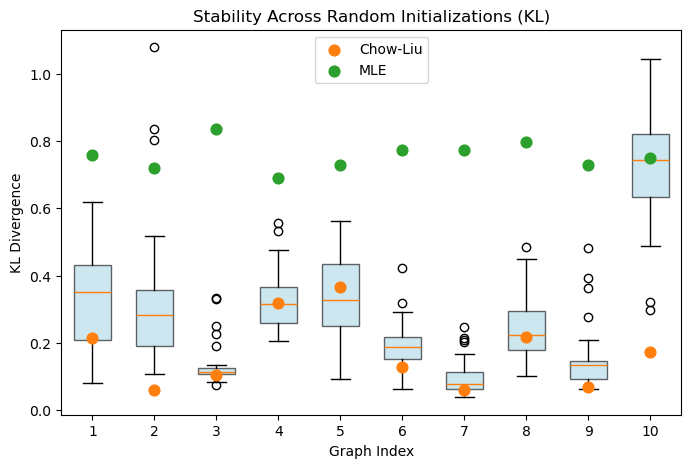

In [27]:
plot_stability_box(results, "KL", "KL Divergence")

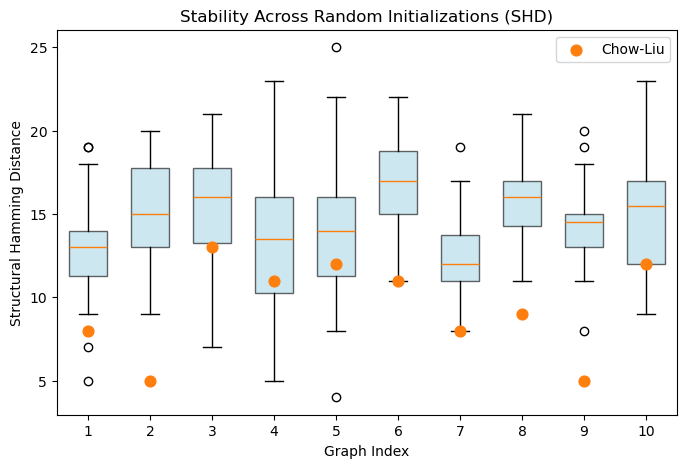

In [28]:
plot_stability_box(results, "SHD", "Structural Hamming Distance")

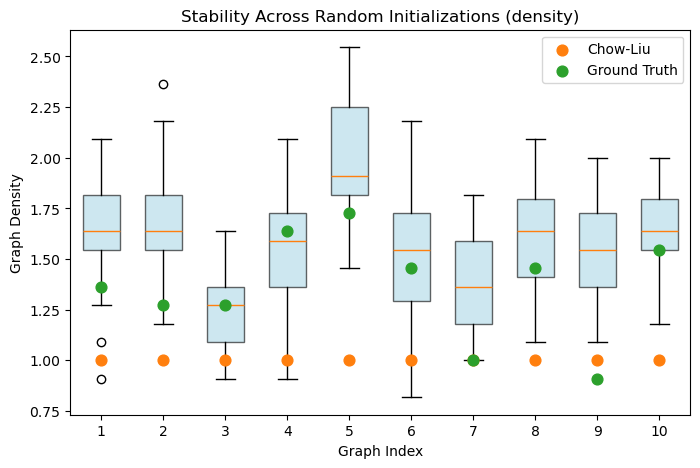

In [29]:
plot_stability_box(results, "density", "Graph Density")

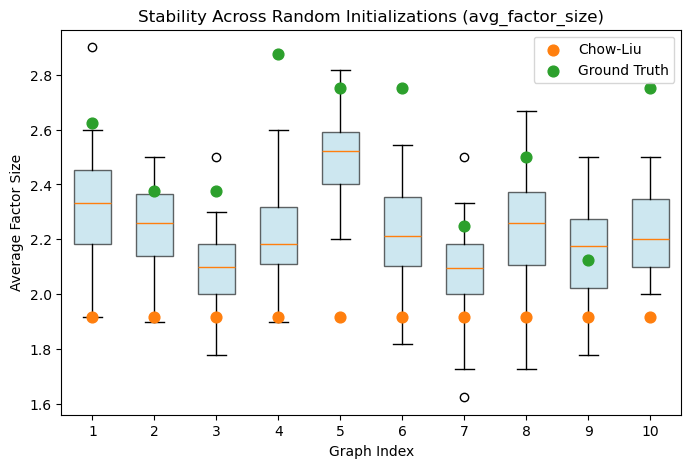

In [30]:
plot_stability_box(results, "avg_factor_size", "Average Factor Size")

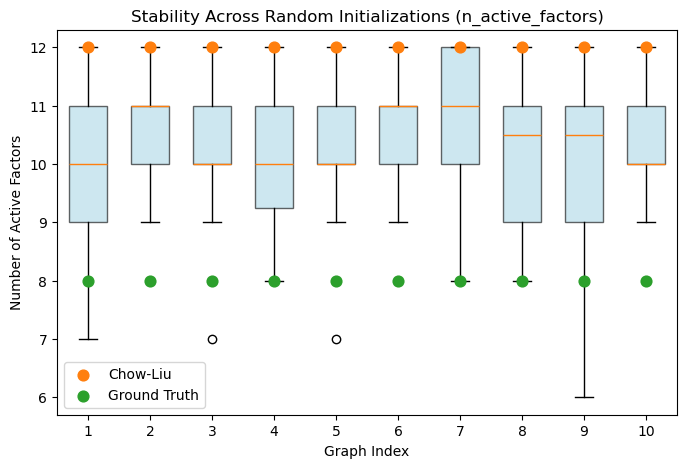

In [31]:
plot_stability_box(results, "n_active_factors", "Number of Active Factors")

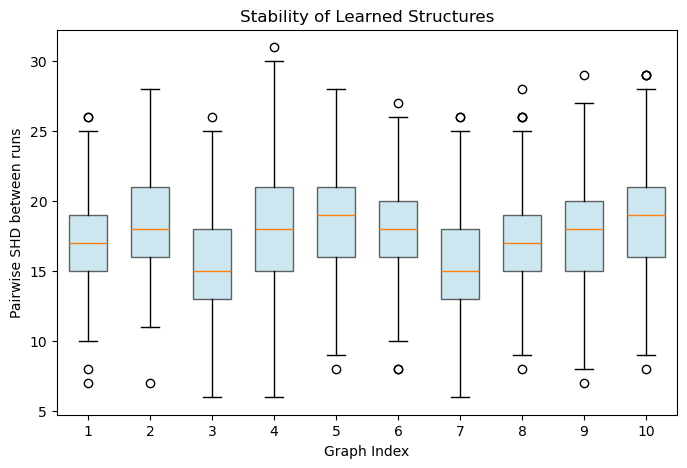

In [43]:
plot_pairwise_shd(results)

# Visualizations

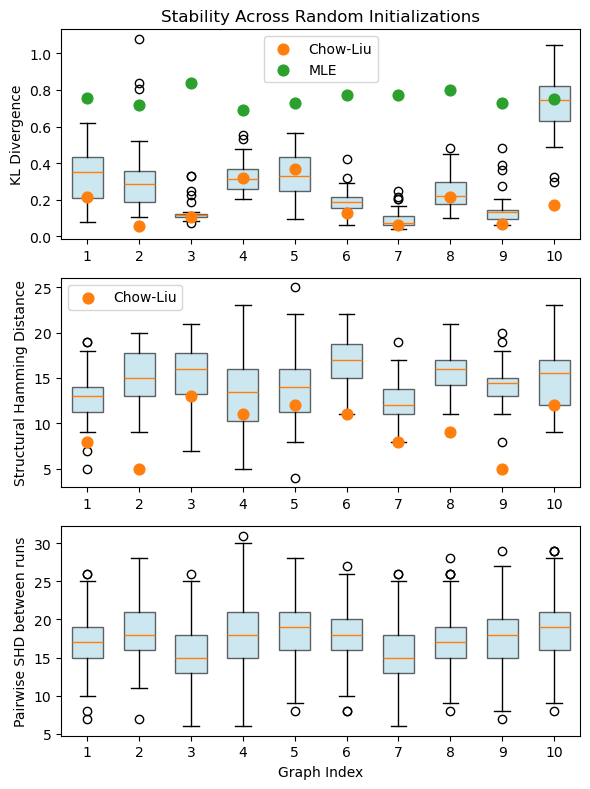

In [46]:
fig, axs = plt.subplots(3,1,figsize=(6,8))

plot_stability_box(results, "KL", "KL Divergence", ax=axs[0])
plot_stability_box(results, "SHD", "Structural Hamming Distance", ax=axs[1])
plot_pairwise_shd(results, ax=axs[2])

axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

axs[0].set_title("Stability Across Random Initializations")
axs[1].set_title(None)
axs[2].set_title(None)

plt.tight_layout()
# plt.savefig('../img/stability.png')
plt.show()